In [469]:
import nltk
import sklearn

print("NLTK version:", nltk.__version__)
print("Scikit-learn version:", sklearn.__version__)

NLTK version: 3.9.1
Scikit-learn version: 1.6.1


In [470]:
import numpy as np
import pandas as pd
# from google.colab import drive
# d=drive.mount('/content/drive')
from google.colab import files
uploaded = files.upload()
ds = pd.read_csv("sms_spam_dataset.csv", encoding='latin-1')
ds.head(10)

Saving sms_spam_dataset.csv to sms_spam_dataset (9).csv


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


In [471]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model Building
# 5. Evaluation
# 6. Impovement
# 7. Website
# 8. Deploy

## 1. Data **cleaning** *

In [472]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [473]:
# drop last 3 columns
ds.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
ds.sample(5)

,v1,v2
62,ham,Its a part of checking IQ
1269,ham,"Tee hee. Off to lecture, cheery bye bye."
4298,ham,Hurt me... Tease me... Make me cry... But in t...
5464,ham,I will treasure every moment we spend together...
3295,ham,Hi there. We have now moved in2 our pub . Woul...


In [474]:
ds['v1'].value_counts()

,count
v1,
ham,4825
spam,747


In [475]:
ds.rename(columns={'v1':'target','v2':'text'}, inplace=True) # rename the column
ds.sample(5)

,target,text
2393,ham,"Okey doke. I'm at home, but not dressed cos la..."
416,ham,Alright i have a new goal now
2474,ham,"Princess, i like to make love &lt;#&gt; time..."
4315,ham,"I can't speak, bcaz mobile have problem. I can..."
652,ham,"Wait, do you know if wesleys in town? I bet sh..."


In [476]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
ds['target'] = encoder.fit_transform(ds['target']) # Encoding for prepare data
ds.head(4)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...


In [477]:
ds.isnull().sum() # check missing value

,0
target,0
text,0


In [478]:
ds.duplicated().sum() # check duplicated value

np.int64(403)

In [479]:
ds = ds.drop_duplicates(keep='first') # remove dupicates without first duplicated value
print(ds.duplicated().sum())
print(ds.shape)

0
(5169, 2)


# ***2. EDA***

In [480]:
print("Dataset:", ds.head(5))

print("Unique_Value: ", ds['target'].value_counts())

print("Value:", ds.value_counts())

Dataset:    target                                               text
0       0  Go until jurong point, crazy.. Available only ...
1       0                      Ok lar... Joking wif u oni...
2       1  Free entry in 2 a wkly comp to win FA Cup fina...
3       0  U dun say so early hor... U c already then say...
4       0  Nah I don't think he goes to usf, he lives aro...
Unique_Value:  target
0    4516
1     653
Name: count, dtype: int64
Value: target  text                                                                                                                                        
1       we tried to contact you re your response to our offer of a new nokia fone and camcorder hit reply or call 08000930705 for delivery              1
        network operator. The service is free. For T & C's visit 80488.biz                                                                              1
        money!!! you r a lucky winner ! 2 claim your prize text money 2 88600 over å£1million

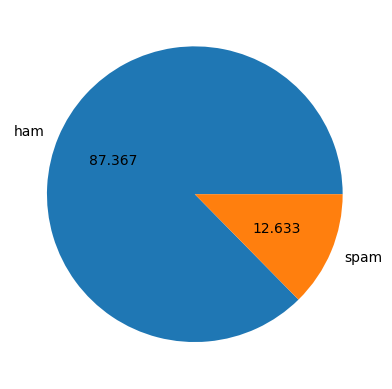

In [481]:
import matplotlib.pyplot as plt  # piechar for better visulization
plt.pie(ds['target'].value_counts(), labels=['ham','spam'],autopct="%0.3f")
plt.show()

# Here data is imbalanced

In [482]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')

ds['num_characters'] = ds['text'].apply(len) # total character
ds['num_words'] =     ds['text'].apply(lambda x:len(nltk.word_tokenize(x))) # total word
ds['num_sentances'] = ds['text'].apply(lambda x:len(nltk.sent_tokenize(x))) # total sentance
ds.head(5)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,target,text,num_characters,num_words,num_sentances
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [483]:
ds.describe()

,target,num_characters,num_words,num_sentances
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [484]:
# only ham
ham_ds = ds[ds['target'] == 0]
ham_ds.describe()

,target,num_characters,num_words,num_sentances
count,4516.0,4516.000000,4516.000000,4516.000000
mean,0.0,70.459256,17.123782,1.820195
std,0.0,56.358207,13.493970,1.383657
min,0.0,2.000000,1.000000,1.000000
25%,0.0,34.000000,8.000000,1.000000
50%,0.0,52.000000,13.000000,1.000000
75%,0.0,90.000000,22.000000,2.000000
max,0.0,910.000000,220.000000,38.000000


In [485]:
# only spam
spam_ds = ds[ds['target'] == 1]
spam_ds.describe()

,target,num_characters,num_words,num_sentances
count,653.0,653.000000,653.000000,653.000000
mean,1.0,137.891271,27.667688,2.970904
std,0.0,30.137753,7.008418,1.488425
min,1.0,13.000000,2.000000,1.000000
25%,1.0,132.000000,25.000000,2.000000
50%,1.0,149.000000,29.000000,3.000000
75%,1.0,157.000000,32.000000,4.000000
max,1.0,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

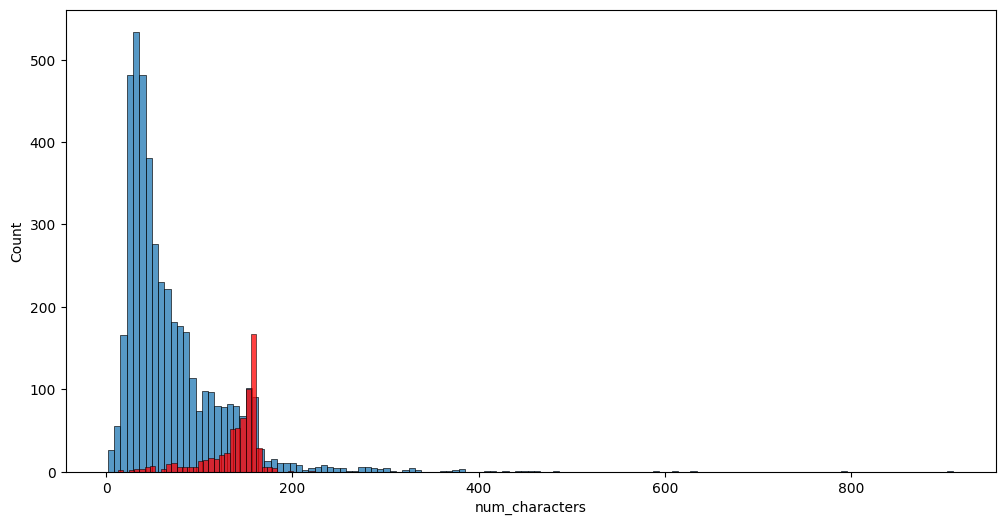

In [486]:
import seaborn as sns
plt.figure(figsize=(12,6))
sns.histplot(ds[ds['target']==0] ['num_characters'])
sns.histplot(ds[ds['target']==1] ['num_characters'],color='red')


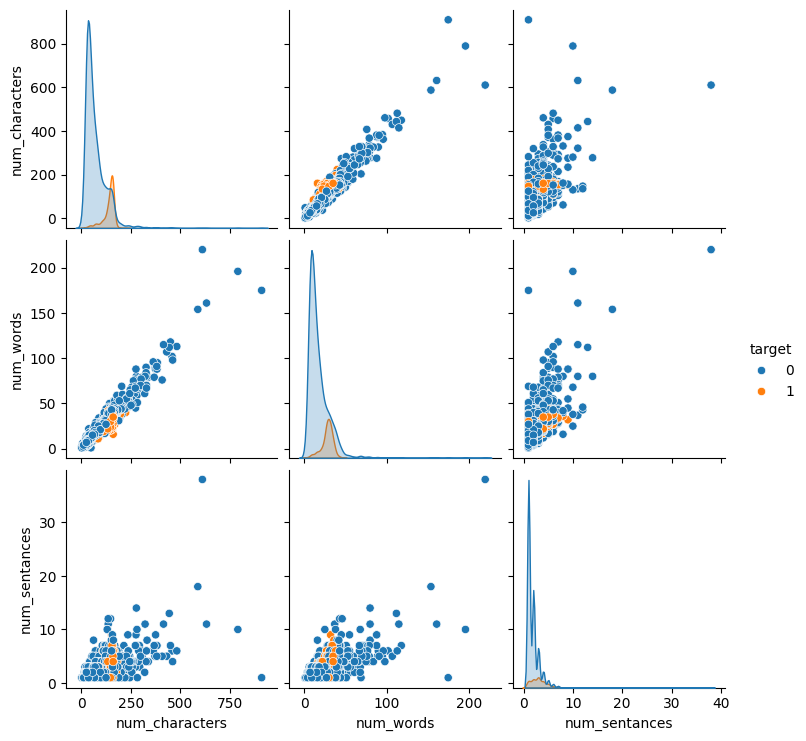

In [487]:
sns.pairplot(ds,hue='target')

<Axes: >

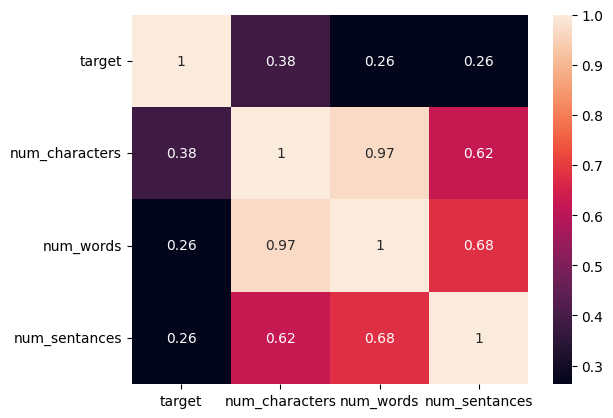

In [488]:
sns.heatmap(ds[['target', 'num_characters', 'num_words', 'num_sentances']].corr(), annot=True) # Correlation visualization

3. Data Preprocessing

      -> Lower Case

      -> Tokenization

      -> Removing Special Characters
      
      -> Stemming

In [489]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
import string

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [490]:
import nltk
# nltk.download('punkt') # Already downloaded in the previous cell
# nltk.download('stopwords') # Already downloaded in the previous cell
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

def transform_test(test):
  text = test.lower()
  text = nltk.word_tokenize(text)

  y = []
  for i in text: # character and number
    if i.isalnum():
      y.append(i)
  text = y[:]
  y.clear()

  for i in text: # loop stopwards
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  for i in text: # stemming
    y.append(ps.stem(i))

  text = y[:]
  y.clear()

  return " ".join(text)

In [491]:
transform_test(' H did you like dancing m presentation on ML and Dl ## % 6 ^ ')

'h like danc present ml dl 6'

In [492]:
ds['transformed_text'] = ds['text'].apply(transform_test)
ds.head()

,target,text,num_characters,num_words,num_sentances,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [493]:
from wordcloud import WordCloud # frequent work show bigger size
wc = WordCloud(width=500, height=500, min_font_size=10,
               background_color='white')

In [494]:
spam_wc = wc.generate(ds[ds['target']==1]['transformed_text'].str.cat(sep=" "))

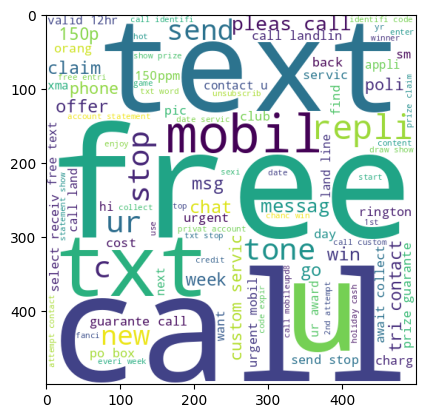

In [495]:
plt.imshow(spam_wc)

In [496]:
spam_corpus=[] # store all word from spam transformed_text
for msg in ds[ds['target']==1]['transformed_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)

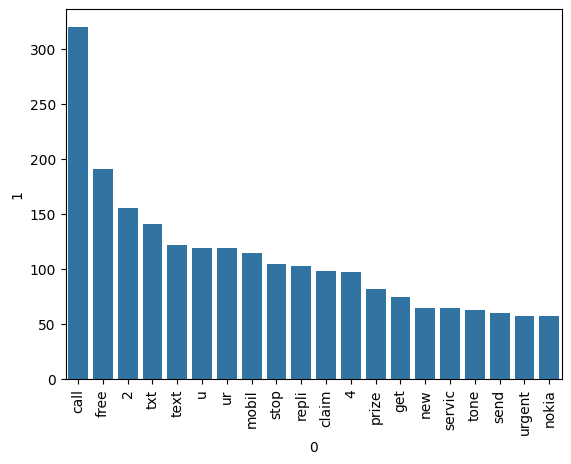

In [497]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(20))[0],
            y=pd.DataFrame(Counter(spam_corpus).most_common(20))[1])
plt.xticks(rotation='vertical')
plt.show()
 # count word frequency

In [498]:
ham_corpus=[] # store all word from spam transformed_text
for msg in ds[ds['target']==0]['transformed_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)

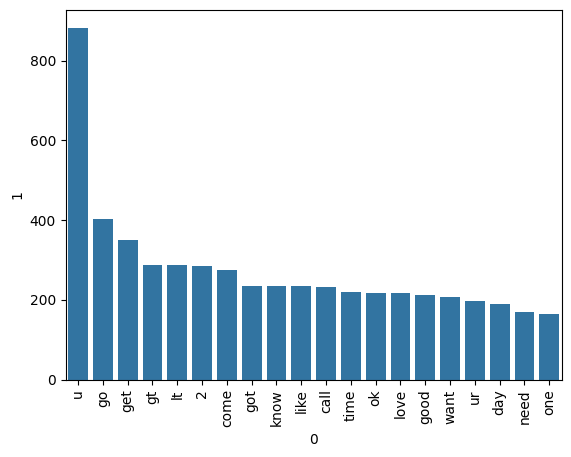

In [499]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(20))[0],
            y=pd.DataFrame(Counter(ham_corpus).most_common(20))[1])
plt.xticks(rotation='vertical')
plt.show()

# ***4. Model Building***

In [500]:
from re import T
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
from sklearn.model_selection import train_test_split


tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(ds['transformed_text']).toarray()
X.shape


(5169, 3000)

In [501]:
# from sklearn.preprocessing import MinMaxScaler # decrease model performance
# scaler = MinMaxScaler()
# X = scaler.fit_transform(X)
# X

In [502]:
# appending the num_character col to X
# X = np.hstack((X,ds['num_characters'].values.reshape(-1,1)))
# X = np.hstack((X,ds['num_words'].values.reshape(-1,1)))
# X

In [503]:
y = ds['target'].values
y

array([0, 0, 1, ..., 0, 0, 0])

In [504]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=2)


In [505]:

from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score

gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))


0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [506]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))


0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [507]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))


0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [535]:
mnb_model = mnb.fit(x_train, y_train)

In [508]:
# tfidf -> mnb

In [509]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [510]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)

abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)


In [511]:
clfs ={
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb
}

In [512]:
def train_classifier(clf,x_train,y_train,x_test,y_test):
  clf.fit(x_train,y_train)
  y_pred = clf.predict(x_test)
  accuracy = accuracy_score(y_test,y_pred)
  precision = precision_score(y_test,y_pred)

  return accuracy, precision

In [513]:
train_classifier(svc,x_train,y_train,x_test,y_test)

(0.9758220502901354, 0.9747899159663865)

In [514]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
  current_accuracy,current_precision = train_classifier(clf,x_train,y_train,x_test,y_test)

  print("For ",name)
  print("Accuracy - ",current_accuracy)
  print("Precision - ",current_precision)

  accuracy_scores.append(current_accuracy)
  precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9709864603481625
Precision -  1.0
For  DT
Accuracy -  0.9332688588007737
Precision -  0.8415841584158416
For  LR
Accuracy -  0.9555125725338491
Precision -  0.96
For  RF
Accuracy -  0.9738878143133463
Precision -  0.9826086956521739
For  AdaBoost
Accuracy -  0.9216634429400387
Precision -  0.8202247191011236
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
For  GBDT
Accuracy -  0.9506769825918762
Precision -  0.9306930693069307
For  xgb
Accuracy -  0.9680851063829787
Precision -  0.9487179487179487


In [515]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),
'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',
ascending=False)
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.973888,0.982609
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LR,0.955513,0.960000
10,xgb,0.968085,0.948718
9,GBDT,0.950677,0.930693
7,BgC,0.958414,0.868217
3,DT,0.933269,0.841584


In [516]:
performance_df1 = pd.melt(performance_df,id_vars='Algorithm')
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.905222
1,NB,Accuracy,0.970986
2,RF,Accuracy,0.973888
3,SVC,Accuracy,0.975822
4,ETC,Accuracy,0.974855
5,LR,Accuracy,0.955513
6,xgb,Accuracy,0.968085
7,GBDT,Accuracy,0.950677
8,BgC,Accuracy,0.958414
9,DT,Accuracy,0.933269


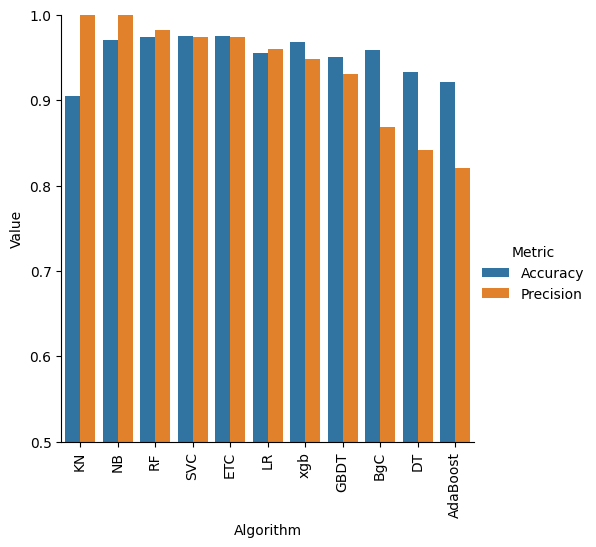

In [517]:
performance_df_melted = performance_df.melt(id_vars='Algorithm', var_name='Metric', value_vars=['Accuracy', 'Precision'], value_name='Value')
sns.catplot(x='Algorithm', y='Value', hue='Metric', data=performance_df_melted, kind='bar', height=5)
plt.xticks(rotation='vertical')
plt.ylim(.5, 1.0)
plt.show()

In [518]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [519]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [520]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [521]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [522]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,KN,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000
1,NB,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000
2,RF,0.973888,0.982609,0.973888,0.982609,0.973888,0.982609,0.973888,0.982609
3,SVC,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790
4,ETC,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576
5,LR,0.955513,0.960000,0.955513,0.960000,0.955513,0.960000,0.955513,0.960000
6,xgb,0.968085,0.948718,0.968085,0.948718,0.968085,0.948718,0.968085,0.948718
7,GBDT,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693
8,BgC,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217
9,DT,0.933269,0.841584,0.933269,0.841584,0.933269,0.841584,0.933269,0.841584


In [523]:
performance_df.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_num_chars,Precision_num_chars
0,KN,0.905222,1.000000,0.905222,1.000000
1,NB,0.970986,1.000000,0.970986,1.000000
2,RF,0.973888,0.982609,0.973888,0.982609
3,SVC,0.975822,0.974790,0.975822,0.974790
4,ETC,0.974855,0.974576,0.974855,0.974576
5,LR,0.955513,0.960000,0.955513,0.960000
6,xgb,0.968085,0.948718,0.968085,0.948718
7,GBDT,0.950677,0.930693,0.950677,0.930693
8,BgC,0.958414,0.868217,0.958414,0.868217
9,DT,0.933269,0.841584,0.933269,0.841584


In [524]:

# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [525]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [526]:
voting.fit(x_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [527]:
VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('mnb', mnb),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('mnb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [528]:

y_pred = voting.predict(x_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9796905222437138
Precision 0.9834710743801653


In [529]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [530]:

from sklearn.ensemble import StackingClassifier

In [531]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [532]:
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9796905222437138
Precision 0.9465648854961832


In [540]:

input_text = ["Win $5000 cash now! Limited time offer. Visit www.winbig.com"]
vector_input = tfidf.transform(input_text)
result = mnb_model.predict(vector_input)[0]
result

np.int64(1)

In [ ]:
import pickle
from google.colab import files

# Vectorizer save & download
pickle.dump(tfidf, open('vectorizer.pkl','wb'))
files.download('vectorizer.pkl')

# Model save & download
pickle.dump(mnb, open('model.pkl','wb'))
files.download('model.pkl')



In [ ]:
# import pickle

# আপনার সেরা মডেলটি যদি 'voting' হয়
# pickle.dump(tfidf, open('vectorizer.pkl','wb'))
# files.download('vectorizer.pkl')

# pickle.dump(voting, open('voting.pkl','wb'))
# files.download('voting.pkl')

# pickle.dump(mnb, open('model.pkl', 'wb'))
# files.download('model.pkl')

# pickle.dump(clf, open('clf.pkl', 'wb'))
# files.download('clf.pkl')
